# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

# Load Dataset

In [2]:
df = pd.read_csv("../data/placement_data.csv")

# Basic Information of Dataset

In [3]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


# Preprocessing

## Missing Values Data

In [4]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

## Duplicates

In [6]:
print(df.duplicated().sum())

0


## Outliers

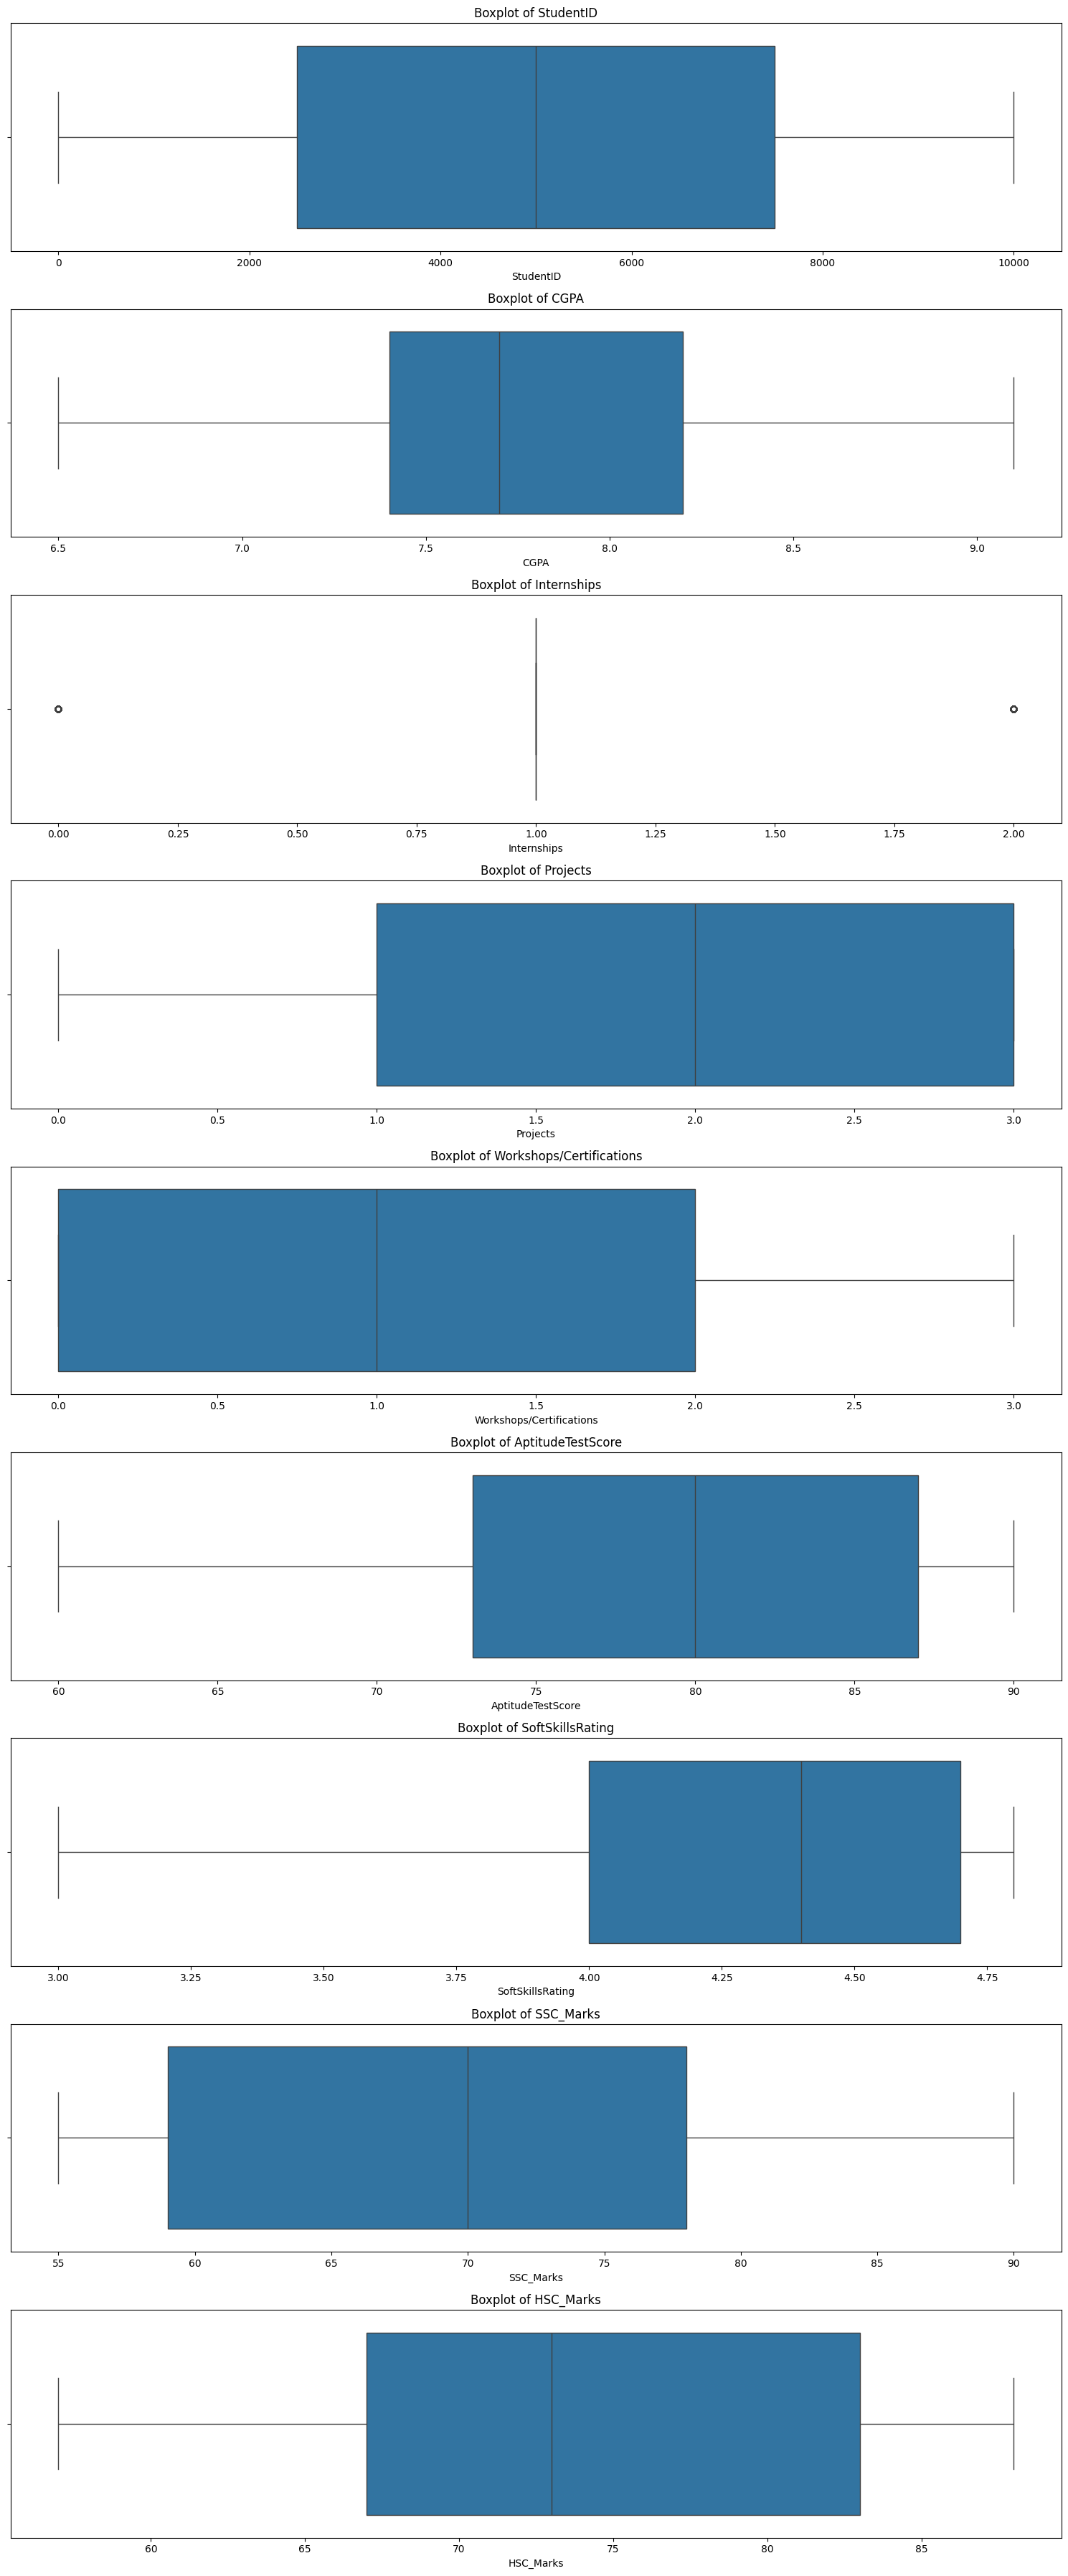

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Set figure size dynamically
plt.figure(figsize=(15, len(numerical_cols) * 4))

# Create boxplots
for i, col in enumerate(numerical_cols, 1):

    plt.subplot(len(numerical_cols), 1, i)

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.tight_layout()

plt.show()

## Remove Student ID

In [8]:
df.drop("StudentID", axis=1, inplace=True)

## Encode Categorical Columns

In [9]:
print(df['ExtracurricularActivities'].unique())

print(df['PlacementTraining'].unique())

print(df['PlacementStatus'].unique())

['No' 'Yes']
['No' 'Yes']
['NotPlaced' 'Placed']


## Use Label Encoding for Categorical columns

In [10]:
le_extra = LabelEncoder()

le_training = LabelEncoder()

df['ExtracurricularActivities'] = le_extra.fit_transform(
    df['ExtracurricularActivities']
)

df['PlacementTraining'] = le_training.fit_transform(
    df['PlacementTraining']
)

In [11]:
le_target = LabelEncoder()

df['PlacementStatus'] = le_target.fit_transform(
    df['PlacementStatus']
)

In [12]:
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1


## Target Split

In [13]:
X = df.drop('PlacementStatus', axis=1)

y = df['PlacementStatus']

In [14]:
print(X.shape)

print(y.shape)

(10000, 10)
(10000,)


## Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)

print(X_test.shape)

(8000, 10)
(2000, 10)


## Save the preprocessed dataset

In [18]:
df.to_csv(
    "../data/processed/cleaned_placement_data.csv",
    index=False
)

In [19]:
saved_df = pd.read_csv(
    "../data/processed/cleaned_placement_data.csv"
)

saved_df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1


# Model Training

## Import models

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [22]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [23]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Store result
    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7945
Decision Tree: 0.7265
Random Forest: 0.7815
KNN: 0.7580
SVM: 0.7790
Gradient Boosting: 0.7910


In [24]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [25]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [26]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7945
Decision Tree: 0.7265
Random Forest: 0.7815
KNN: 0.7580
SVM: 0.7790
Gradient Boosting: 0.7910
XGBoost: 0.7785
[LightGBM] [Info] Number of positive: 3369, number of negative: 4631
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421125 -> initscore=-0.318157
[LightGBM] [Info] Start training from score -0.318157
LightGBM: 0.7850
CatBoost: 0.7815


## Feature Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=0
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [32]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7945
Decision Tree: 0.7250
Random Forest: 0.7820
KNN: 0.7715
SVM: 0.7930
Gradient Boosting: 0.7910
XGBoost: 0.7785
LightGBM: 0.7850


D:\Projects\DevOps\placement_prediction_project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatBoost: 0.7815


## Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

print(grid.best_score_)

{'C': 0.01}
0.7997500000000001


In [34]:
params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(probability=True),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

print(grid.best_score_)

{'C': 0.1, 'kernel': 'linear'}
0.8001250000000001


# Final Model Code

In [41]:
final_model = SVC(
    C=0.1,
    kernel='linear',
    probability=True,
    random_state=42
)

final_model.fit(X_train, y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
from sklearn.metrics import classification_report

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[952 220]
 [189 639]]


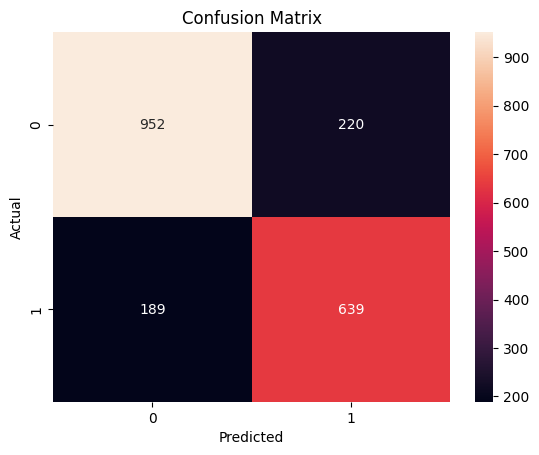

In [44]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [45]:
from sklearn.metrics import roc_auc_score

probabilities = final_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8754894807999869


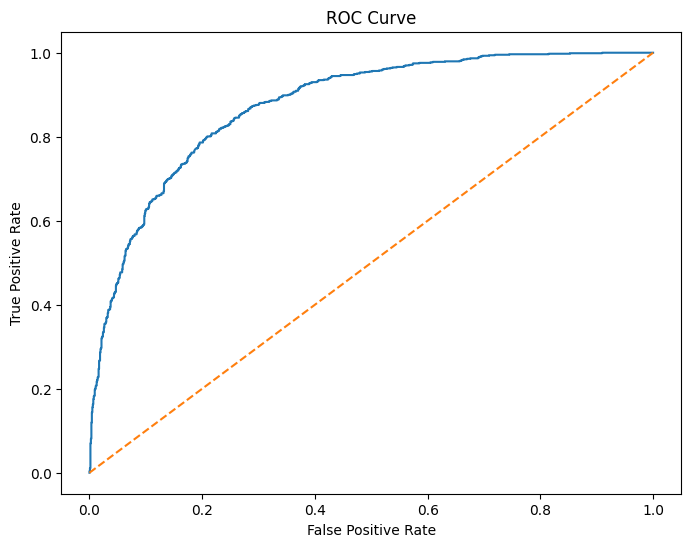

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Saving the final model

In [47]:
joblib.dump(final_model, "../model.pkl")

['../model.pkl']

In [48]:
joblib.dump(scaler, "../scaler.pkl")

['../scaler.pkl']

In [49]:
joblib.dump(le_extra, "../le_extra.pkl")

joblib.dump(le_training, "../le_training.pkl")

joblib.dump(le_target, "../le_target.pkl")

['../le_target.pkl']

In [50]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "../feature_columns.pkl")

['../feature_columns.pkl']

# Track Final Model

In [51]:
import mlflow
import mlflow.sklearn

with mlflow.start_run():

    final_model = SVC(
        C=0.1,
        kernel='linear',
        probability=True,
        random_state=42
    )

    final_model.fit(X_train, y_train)

    predictions = final_model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    roc_auc = roc_auc_score(
        y_test,
        final_model.predict_proba(X_test)[:,1]
    )

    mlflow.log_param("model", "SVC")

    mlflow.log_param("C", 0.1)

    mlflow.log_param("kernel", "linear")

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(final_model, "model")

    print("Accuracy:", accuracy)

    print("ROC-AUC:", roc_auc)

2026/05/13 21:27:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/13 21:27:13 INFO mlflow.store.db.utils: Updating database tables
2026/05/13 21:27:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 21:27:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.7955
ROC-AUC: 0.8754894807999869
